In [1]:
from vmc_ising import output_dir, get_config, get_lattice, default_config
from misc_utils import read_jsonl_to_df, keep_serializable, concat_columns, column_to
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from nqs_playground_helpers import safe_exp
import torch
from pathlib import Path
from collections.abc import Iterable
import jsonlines
import pandas as pd

Running dilated_nns_xors.py


In [2]:
df = read_jsonl_to_df(output_dir.glob("*/results.jsonl")).fillna(
    keep_serializable(default_config)
)

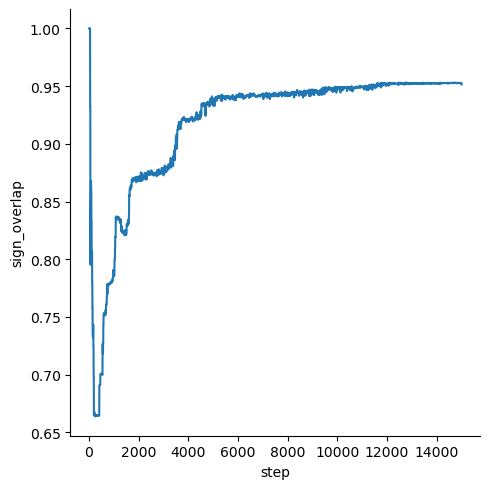

In [3]:
sns.relplot(df.query("task_id == 13"), x="step", y="sign_overlap", kind="line")

In [6]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'overlap'],
      dtype='object')

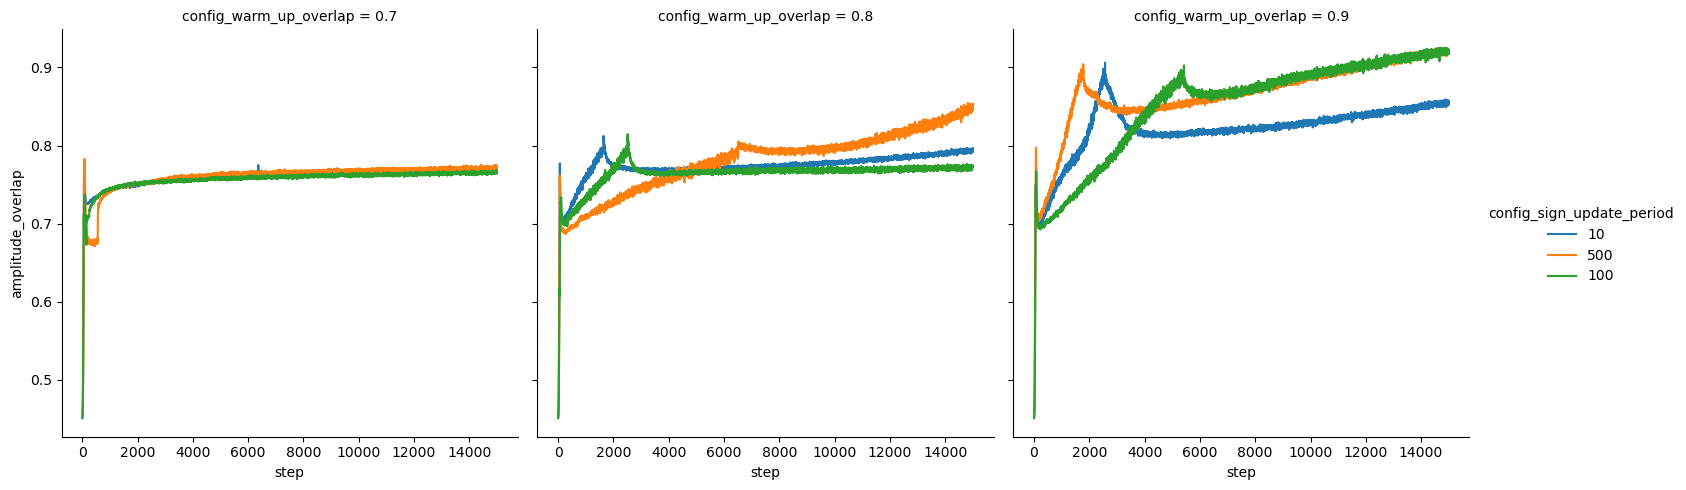

In [15]:
sns.relplot(
    df.query("task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7").pipe(column_to(str, "config_sign_update_period")),
    x="step",
    y="amplitude_overlap",
    kind="line",
    hue="config_sign_update_period",
    col="config_warm_up_overlap",
    col_wrap=3
)

In [20]:
df.query('task_id == 10').iloc[0]

config_n_samples                                          10000
config_lr                                                 0.001
config_batch_size                                         10000
config_weight_decay                                           0
config_max_iter                                           15000
config_lattice                                        kagome2x3
config_J2                                                     1
config_use_symmetries                                     False
config_spin_inversion                                      None
config_eval_set_max_size                                  50000
config_device                                              auto
config_random_seed                                         None
config_dilations                                           None
config_hidden_channels                             [32, 32, 32]
config_warm_up_overlap                                      0.7
config_sign_update_period               

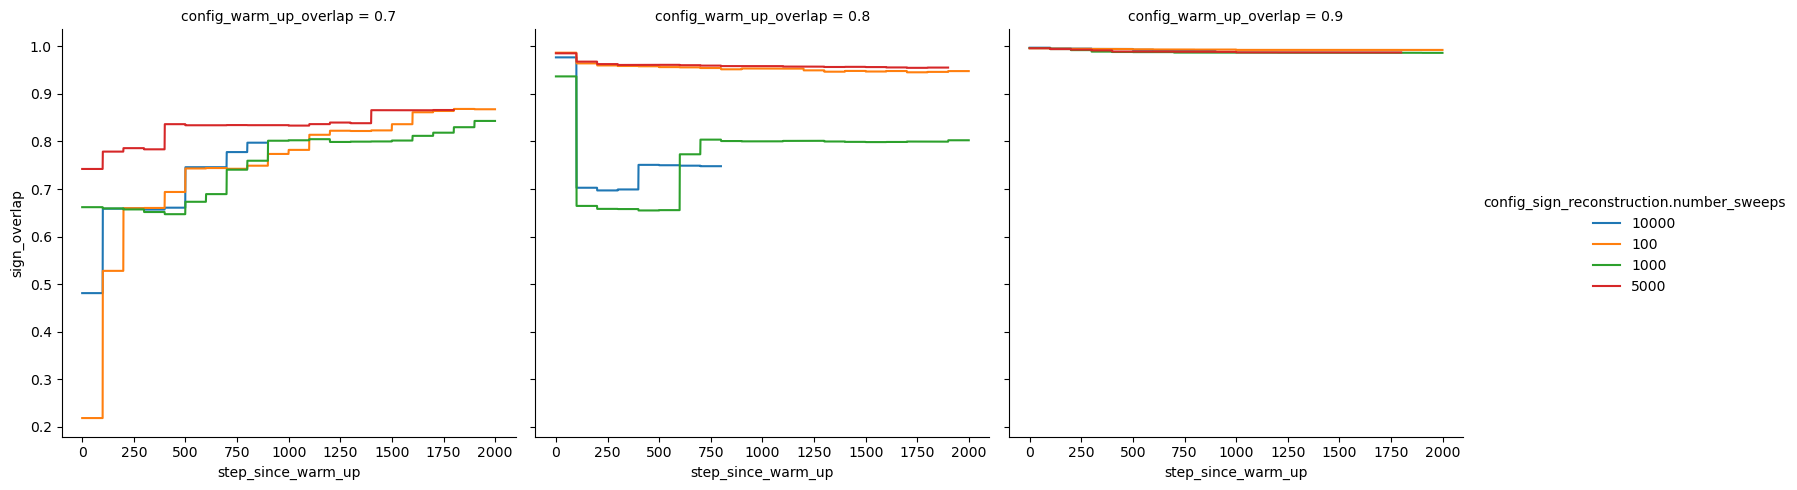

In [12]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and step_since_warm_up < 2000"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="sign_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

In [9]:
df.columns

Index(['config_n_samples', 'config_lr', 'config_batch_size',
       'config_weight_decay', 'config_max_iter', 'config_lattice', 'config_J2',
       'config_use_symmetries', 'config_spin_inversion',
       'config_eval_set_max_size', 'config_device', 'config_random_seed',
       'config_dilations', 'config_hidden_channels', 'config_warm_up_overlap',
       'config_sign_update_period', 'config_sign_reconstruction.method',
       'config_sign_reconstruction.number_sweeps', 'config_warm_up.sign_noise',
       'config_log_prob_fn', 'config_kernel_size', 'amplitude_overlap',
       '‖∇E‖₂', 'E_full_delta', 'ipr', 'step', 'E_variance', 'start_timestamp',
       'task_id', 'device', 'warm_up', 'sign_overlap', 'step_since_warm_up',
       'signs_updated', 'signs_updated_at', 'step_since_signs_updated',
       'config_sign_reconstruction.repetitions', 'overlap'],
      dtype='object')

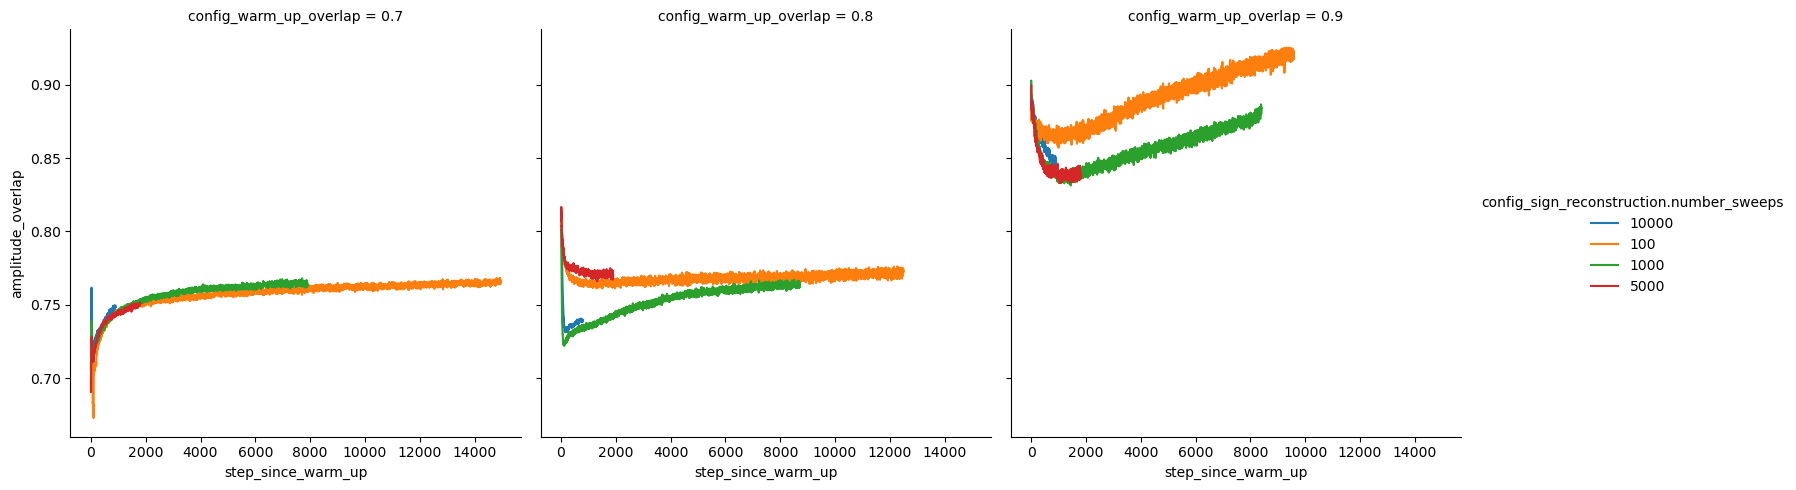

In [10]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="step_since_warm_up",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)

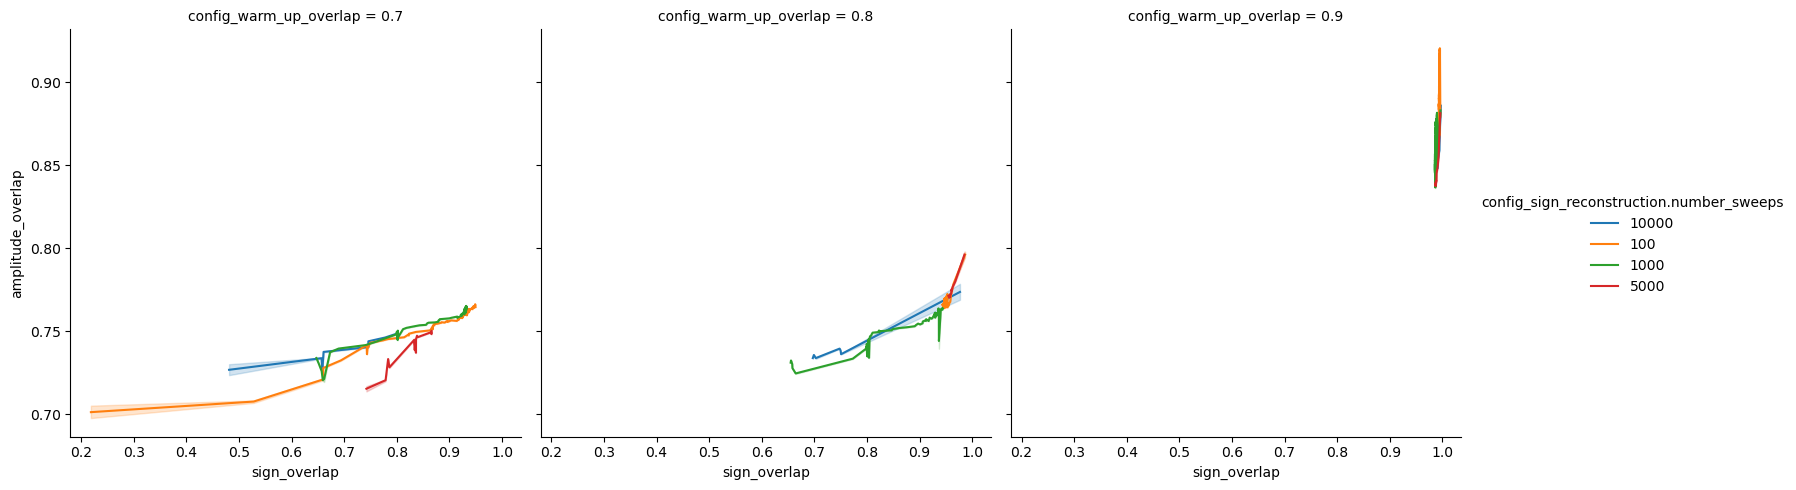

In [13]:
sns.relplot(
    df.query(
        "task_id > 0 and 0.9 >= config_warm_up_overlap >= 0.7 and config_sign_update_period == 100"
        "and not warm_up"
    ).pipe(column_to(str, "config_sign_reconstruction.number_sweeps")),
    x="sign_overlap",
    y="amplitude_overlap",
    kind="line",
    col="config_warm_up_overlap",
    hue="config_sign_reconstruction.number_sweeps",
)